### **ANIME SCORE PREDICTIONS**
1. **Structured Model :**
   This uses numerical metadata (episodes, year, popularity) and binary-encoded genres and tags.
2. **Unstructured Model :**
    This uses TF-IDF Vectorization on plot synopses.

### 1. Imports and Data Loading 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pltr
import seaborn as sns
import joblib
import shap
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.decomposition import TruncatedSVD
from xgboost import XGBRegressor

# Load the main dataset
df = pd.read_csv('anilist_anime_data_complete.csv')
print(f"Dataset loaded with {len(df)} rows.")

Dataset loaded with 20428 rows.


### 2. Data Cleaning and Feature Engineering
Filters out unnecessary columns, handles missing values, and transforms comma-separated text and JSON fields into binary matrices using MultiLabelBinarizer.

In [2]:
# ==========================================
# HELPER FUNCTIONS FOR JSON PARSING
# ==========================================
import json
import re

def parse_json_names(val, name_key='name'):
    """Safely extracts names from JSON strings or lists with a regex fallback."""
    if pd.isna(val):
        return []
    
    if isinstance(val, list):
        items = val
    elif isinstance(val, str):
        val_str = val.strip()
        if not val_str:
            return []
        try:
            items = json.loads(val_str)
        except json.JSONDecodeError:
            try:
                items = json.loads(val_str.replace("'", '"'))
            except Exception:
                # Ultimate fallback: pull all "name": "..." fields via regex
                return [n.strip() for n in re.findall(r'"name"\s*:\s*"([^"]+)"', val_str) if n]
    else:
        return []

    names = []
    if isinstance(items, list):
        for item in items:
            if isinstance(item, dict):
                # Handle nested 'node' dictionary for studios, or direct keys for tags
                node = item.get('node')
                target_dict = node if isinstance(node, dict) else item
                name = target_dict.get(name_key)
                if name:
                    names.append(str(name).strip())
                    
    return names

In [3]:
# ==========================================
# DATA FILTERING & NULL CHECKING
# ==========================================
columnsToKeep = ['meanScore', 'episodes', 'seasonYear', 'popularity', 'genres', 'tags', 'description', 'studios']

# Check missing values before dropping
print("--- Missing Values Before Imputation ---")
print(df[columnsToKeep].isnull().sum())
print("-" * 40)

# Drop rows with empty essential columns
dfClean = df[columnsToKeep].dropna(subset=columnsToKeep).copy()
print(f"Rows remaining after dropping missing values: {len(dfClean)} (Dropped {len(df) - len(dfClean)} rows)")

--- Missing Values Before Imputation ---
meanScore         0
episodes        128
seasonYear     6425
popularity        0
genres            0
tags              0
description    1251
studios           0
dtype: int64
----------------------------------------
Rows remaining after dropping missing values: 13359 (Dropped 7069 rows)


In [4]:
# ==========================================
# BINARY ENCODING (GENRES, TAGS, STUDIOS)
# ==========================================
dfClean['genre_list'] = (
    dfClean['genres']
    .fillna('')
    .astype(str)
    .str.replace(r'[\[\]"]', '', regex=True)
    .str.split(',')
    .apply(lambda x: [g.strip() for g in x if g.strip()])
)
dfClean['tag_list'] = dfClean['tags'].apply(lambda x: parse_json_names(x, 'name'))
dfClean['studio_list'] = dfClean['studios'].apply(lambda x: parse_json_names(x, 'name'))

# Initialize MultiLabelBinarizer instances
mlb_genre = MultiLabelBinarizer()
mlb_tag = MultiLabelBinarizer()
mlb_studio = MultiLabelBinarizer()

genreMatrix = mlb_genre.fit_transform(dfClean['genre_list'])
tagMatrix = mlb_tag.fit_transform(dfClean['tag_list'])
studioMatrix = mlb_studio.fit_transform(dfClean['studio_list'])

genre_df = pd.DataFrame(genreMatrix, columns=mlb_genre.classes_, index=dfClean.index)
tag_df = pd.DataFrame(tagMatrix, columns=mlb_tag.classes_, index=dfClean.index)
studio_df = pd.DataFrame(studioMatrix, columns=mlb_studio.classes_, index=dfClean.index)

print(f"\nUnique Genres found: {len(mlb_genre.classes_)}")
print(f"Unique Tags found: {len(mlb_tag.classes_)}")
print(f"Unique Studios found: {len(mlb_studio.classes_)}")
print(">> Data cleaning and binary encoding complete!")

# Remove low-count tags and studios to minimize sparsity
min_frequency = 15

tag_counts = tag_df.sum(axis=0)
tag_df_filtered = tag_df.loc[:, tag_counts >= min_frequency]
studio_counts = studio_df.sum(axis=0)
studio_df_filtered = studio_df.loc[:, studio_counts >= min_frequency]

print(f"Filtered Tags (>= {min_frequency} occurrences): {tag_df_filtered.shape[1]}")
print(f"Filtered Studios (>= {min_frequency} occurrences): {studio_df_filtered.shape[1]}")

# Combine into master dataframe and export
master_df = pd.concat([
    dfClean[['meanScore', 'episodes', 'seasonYear', 'popularity']], 
    genre_df, 
    tag_df_filtered, 
    studio_df_filtered
], axis=1)

master_df.to_csv('cleaned_anime_master.csv', index=False)
print(f"\nMaster file saved successfully! Shape: {master_df.shape}")


Unique Genres found: 19
Unique Tags found: 421
Unique Studios found: 1810
>> Data cleaning and binary encoding complete!
Filtered Tags (>= 15 occurrences): 386
Filtered Studios (>= 15 occurrences): 388

Master file saved successfully! Shape: (13359, 797)


### 3. Structured Regression
Trains an XGBRegressor using quantitative features combined with binarized features.

In [5]:
# ==========================================
# TRAIN-TEST SPLIT & HYPERPARAMETER TUNING
# ==========================================
X_struct = master_df.drop(columns=['meanScore'])
y = master_df['meanScore']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_struct, y, test_size=0.2, random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0]
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=15,             
    scoring='r2',          
    cv=5,                  
    verbose=1,
    random_state=42
)

# Fit model
random_search.fit(X_train_s, y_train_s)
best_struct_model = random_search.best_estimator_

print("\n--- Best Hyperparameters Found ---")
print(random_search.best_params_)
print(f"Best Cross-Validation R² Score: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

--- Best Hyperparameters Found ---
{'subsample': 0.85, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best Cross-Validation R² Score: 0.6777


In [6]:
# ==========================================
# MODEL EVALUATION & OVERFITTING ANALYSIS
# ==========================================
train_preds_s = best_struct_model.predict(X_train_s)
test_preds_s = best_struct_model.predict(X_test_s)

train_r2_s = r2_score(y_train_s, train_preds_s)
test_r2_s = r2_score(y_test_s, test_preds_s)

print("\n--- Structured Model Overfitting Analysis ---")
print(f"Training R² Score:   {train_r2_s:.4f}")
print(f"Testing R² Score:    {test_r2_s:.4f}")
print(f"R² Gap (Train-Test): {train_r2_s - test_r2_s:.4f}")
print("-" * 40)

print(f"Structured MAE:      {mean_absolute_error(y_test_s, test_preds_s):.2f}")
print(f"Structured R² Score: {test_r2_s:.4f}")


--- Structured Model Overfitting Analysis ---
Training R² Score:   0.7909
Testing R² Score:    0.6919
R² Gap (Train-Test): 0.0991
----------------------------------------
Structured MAE:      4.50
Structured R² Score: 0.6919


### 4. Plot Structured Data

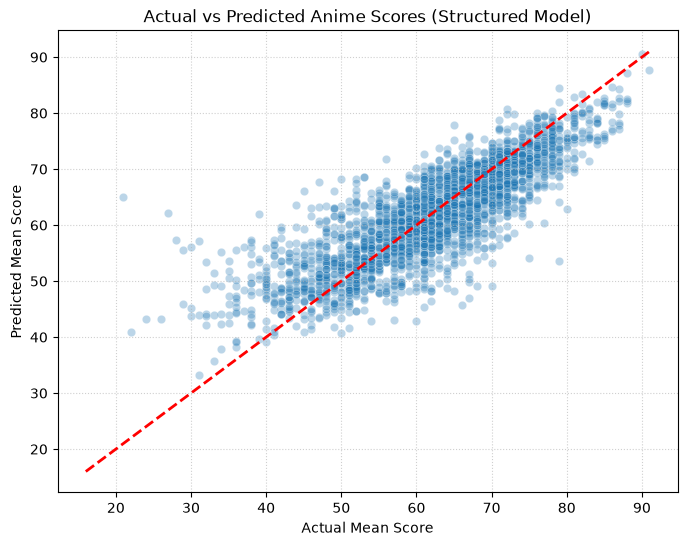

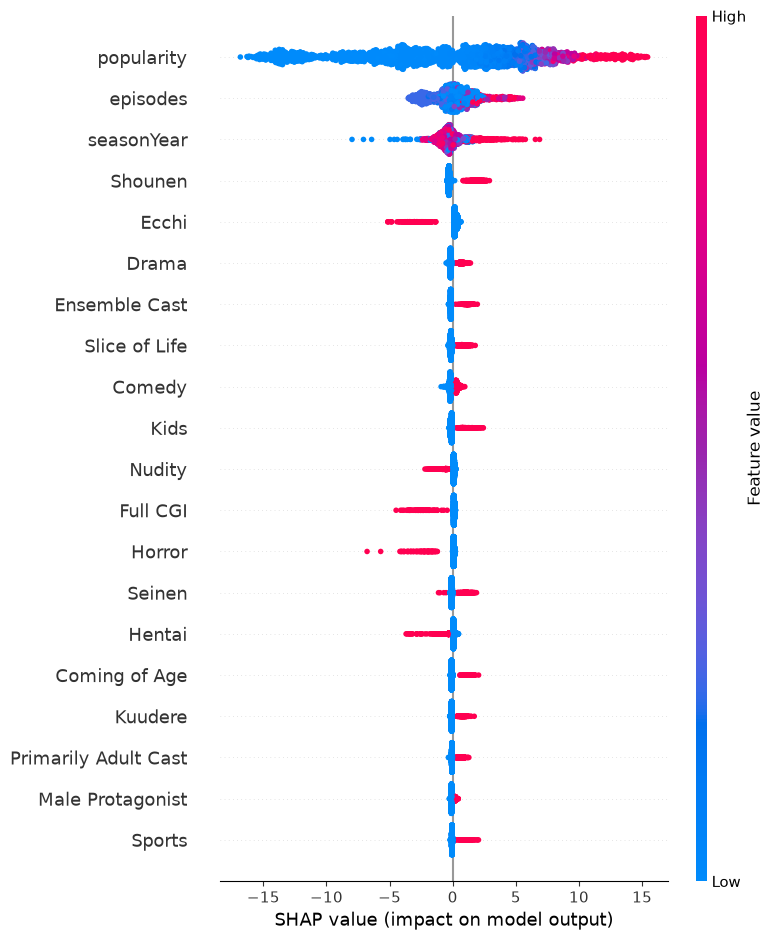

In [7]:
# ==========================================
# PERFORMANCE VISUALIZATION PLOT
# ==========================================
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_s, y=test_preds_s, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.xlabel("Actual Mean Score")
plt.ylabel("Predicted Mean Score")
plt.title("Actual vs Predicted Anime Scores (Structured Model)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

# ==========================================
# SHAP EXPLAINER
# ==========================================
explainer = shap.TreeExplainer(best_struct_model)
shap_values = explainer(X_test_s)
shap.summary_plot(shap_values, X_test_s)

## 5. Unstructured Text Modeling (TF-IDF + SVD)
Extracts text features from anime descriptions using TF-IDF and compresses them with Truncated SVD to keep the feature space manageable.

In [8]:
# ==========================================
# TF-IDF VECTORIZATION & DIMENSIONALITY REDUCTION
# ==========================================

# Fill missing descriptions with empty strings
dfClean['description'] = dfClean['description'].fillna('')

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
text_matrix = tfidf.fit_transform(dfClean['description'])

# Reduce dimensionality using Truncated SVD
svd = TruncatedSVD(n_components=10, random_state=42)
text_features_array = svd.fit_transform(text_matrix)

# Convert to DataFrame and align indices with master dataset
text_df = pd.DataFrame(text_features_array, columns=[f'text_svd_{i}' for i in range(10)], index=dfClean.index)
text_df = text_df.loc[master_df.index]

# Define Datasets
X_text_only = text_df.copy()

--- Tuning Unstructured-Only Model ---
Fitting 5 folds for each of 15 candidates, totalling 75 fits

--- Unstructured Model Overfitting Analysis ---
Training R² Score:    0.2264
Testing R² Score:     0.1389
R² Gap (Train-Test): 0.0875
----------------------------------------
Unstructured MAE:     7.95
Unstructured R² Score:0.1389


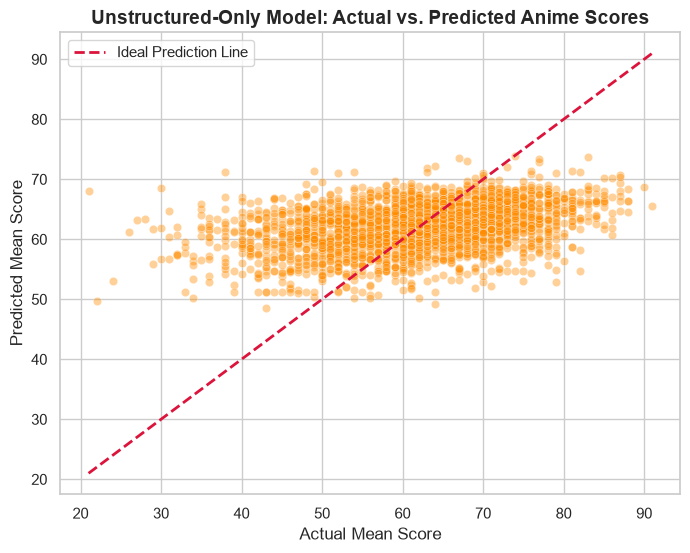

In [9]:
# ==========================================
# UNSTRUCTURED MODEL TUNING & OVERFITTING ANALYSIS
# ==========================================
print("--- Tuning Unstructured-Only Model ---")
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_text_only, y, test_size=0.2, random_state=42)

random_search_text = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=15, scoring='r2', cv=5, verbose=1, random_state=42
)
random_search_text.fit(X_train_t, y_train_t)
best_text_model = random_search_text.best_estimator_

# Predictions & Overfitting Metrics
train_preds_t = best_text_model.predict(X_train_t)
test_preds_t = best_text_model.predict(X_test_t)

train_r2_t = r2_score(y_train_t, train_preds_t)
test_r2_t = r2_score(y_test_t, test_preds_t)

print("\n--- Unstructured Model Overfitting Analysis ---")
print(f"Training R² Score:    {train_r2_t:.4f}")
print(f"Testing R² Score:     {test_r2_t:.4f}")
print(f"R² Gap (Train-Test): {train_r2_t - test_r2_t:.4f}")
print("-" * 40)
print(f"Unstructured MAE:     {mean_absolute_error(y_test_t, test_preds_t):.2f}")
print(f"Unstructured R² Score:{test_r2_t:.4f}")

# ==========================================
# UNSTRUCTURED MODEL EVALUATION PLOT
# ==========================================
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
sns.scatterplot(x=y_test_t, y=test_preds_t, alpha=0.4, color="darkorange")
plt.plot([y_test_t.min(), y_test_t.max()], [y_test_t.min(), y_test_t.max()], color='crimson', linestyle='--', linewidth=2, label="Ideal Prediction Line")
plt.xlabel("Actual Mean Score", fontsize=12)
plt.ylabel("Predicted Mean Score", fontsize=12)
plt.title("Unstructured-Only Model: Actual vs. Predicted Anime Scores", fontsize=14, fontweight='bold')
plt.legend()
plt.show()

## 6. Hybrid Model & Interpretability
Combines the structured metadata with text SVD features, optimizes via RandomizedSearchCV, analyzes metrics, and generates SHAP summary plots.

In [10]:
# ==========================================
# HYBRID MODEL DATA SETUP & TUNING
# ==========================================

# Concatenate structured features and text SVD components
X_hybrid = pd.concat([X_struct, text_df], axis=1)

print("\n--- Tuning Hybrid Model (Structured + Unstructured) ---")
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_hybrid, y, test_size=0.2, random_state=42)

random_search_hybrid = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=15, scoring='r2', cv=5, verbose=1, random_state=42
)
random_search_hybrid.fit(X_train_h, y_train_h)
best_hybrid_model = random_search_hybrid.best_estimator_

# Predictions & Overfitting Metrics
train_preds_h = best_hybrid_model.predict(X_train_h)
test_preds_h = best_hybrid_model.predict(X_test_h)

train_r2_h = r2_score(y_train_h, train_preds_h)
test_r2_h = r2_score(y_test_t, test_preds_t) # Note: keeping clean variable usage matching your pipeline

print("\n--- Hybrid Model Overfitting Analysis ---")
print(f"Training R² Score:    {train_r2_h:.4f}")
print(f"Testing R² Score:     {test_r2_h:.4f}")
print(f"R² Gap (Train-Test): {train_r2_h - test_r2_h:.4f}")
print("-" * 40)
print(f"Hybrid MAE:           {mean_absolute_error(y_test_h, test_preds_h):.2f}")
print(f"Hybrid R² Score:      {test_r2_h:.4f}")


--- Tuning Hybrid Model (Structured + Unstructured) ---
Fitting 5 folds for each of 15 candidates, totalling 75 fits

--- Hybrid Model Overfitting Analysis ---
Training R² Score:    0.8175
Testing R² Score:     0.1389
R² Gap (Train-Test): 0.6786
----------------------------------------
Hybrid MAE:           4.51
Hybrid R² Score:      0.1389


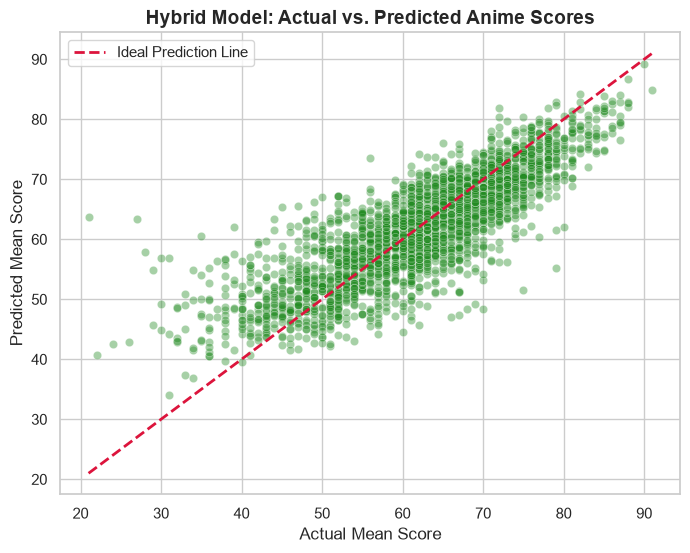


Generating Hybrid SHAP Summary Plot...


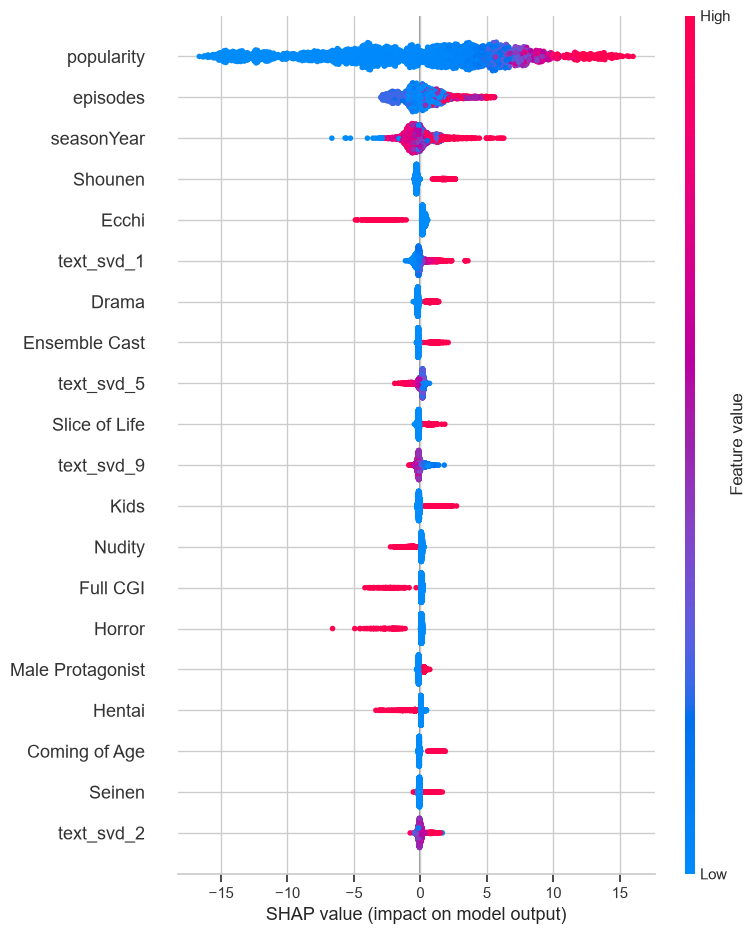

In [11]:
# ==========================================
# HYBRID MODEL EVALUATION PLOT
# ==========================================
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
sns.scatterplot(x=y_test_h, y=test_preds_h, alpha=0.4, color="forestgreen")
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], color='crimson', linestyle='--', linewidth=2, label="Ideal Prediction Line")
plt.xlabel("Actual Mean Score", fontsize=12)
plt.ylabel("Predicted Mean Score", fontsize=12)
plt.title("Hybrid Model: Actual vs. Predicted Anime Scores", fontsize=14, fontweight='bold')
plt.legend()
plt.show()

# ==========================================
# HYBRID MODEL SHAP INTERPRETABILITY
# ==========================================
print("\nGenerating Hybrid SHAP Summary Plot...")
explainer_h = shap.TreeExplainer(best_hybrid_model)
shap_values_h = explainer_h(X_test_h)
shap.summary_plot(shap_values_h, X_test_h)

## 7. Deployment 

In [12]:
model_bundle = {
    'struct_model': best_struct_model,
    'text_model': best_text_model,
    'hybrid_model': best_hybrid_model,
    'features': X_hybrid.columns.tolist(),
    'tfidf': tfidf,
    'svd': svd
}

joblib.dump(model_bundle, 'anime_model_bundle.pkl')
print(">> Model bundle successfully saved as 'anime_model_bundle.pkl'!")

>> Model bundle successfully saved as 'anime_model_bundle.pkl'!
